#Task 1: Understanding Sequential Data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#1.1
• Load and explore the AAPL stock price dataset.

In [ ]:
data =pd.read_csv('/content/drive/MyDrive/AAPL.csv')
data.head()

,Date,Close,Open,High,Low,Volume
0,1/17/2020,138.31,136.54,138.330,136.16,5623336
1,1/16/2020,137.98,137.32,138.190,137.01,4320911
2,1/15/2020,136.62,136.00,138.055,135.71,4045952
3,1/14/2020,135.82,136.28,137.139,135.55,3683458
4,1/13/2020,136.60,135.48,136.640,135.07,3531572


#1.2
• Visualize the time series data (closing prices).

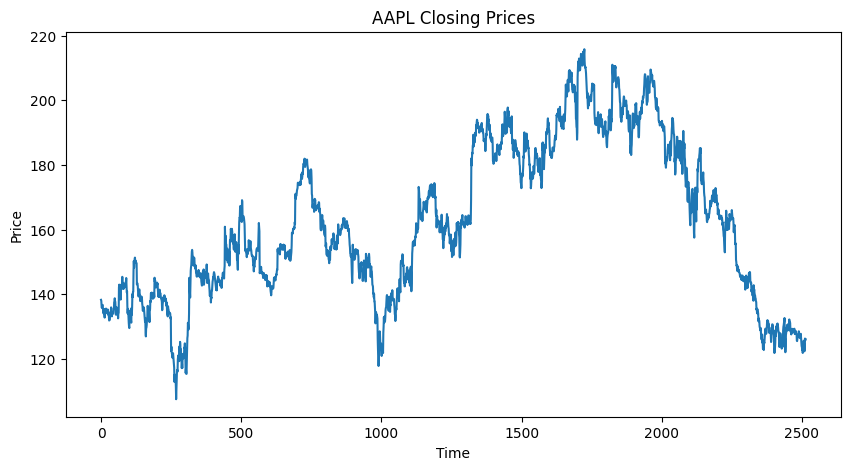

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("AAPL Closing Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()


#1.3
• Reverse the data for chronological order and plot again.

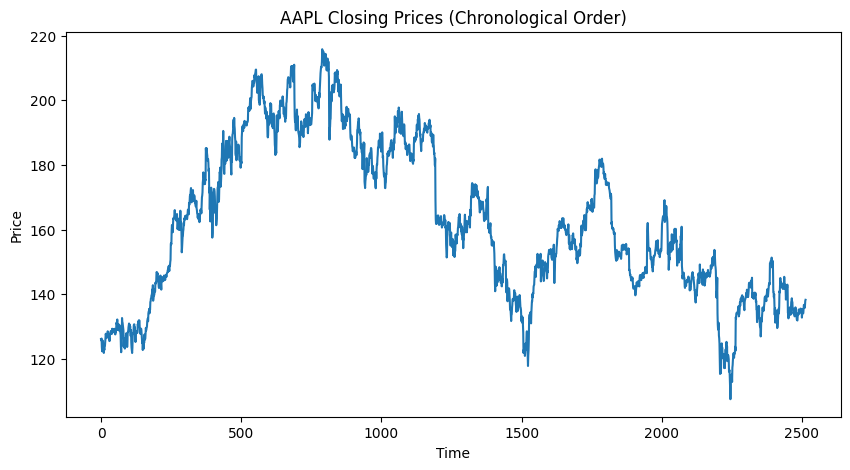

In [ ]:
data_rev = data.iloc[::-1].reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(data_rev['Close'])
plt.title("AAPL Closing Prices (Chronological Order)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()


#1.4
• Extract and reshape the closing price values for modeling.

In [ ]:
close_prices = data_rev['Close'].values
close_prices = close_prices.reshape(-1,1)

print(close_prices.shape)

(2514, 1)


#Task 2: Implementing a Simple RNN Forward Pass

In [ ]:
import tensorflow as tf

#2.1
• Implement a forward pass for a simple RNN with two time steps using TensorFlow.

In [ ]:
x0 = tf.constant([[0.5]], dtype=tf.float32)
x1 = tf.constant([[0.8]], dtype=tf.float32)


#2.2
• Define feedforward and recurrent weight matrices.

In [ ]:
Wx = tf.constant([[1.0]], dtype=tf.float32)
Wh = tf.constant([[0.5]], dtype=tf.float32)
b  = tf.constant([[0.0]], dtype=tf.float32)


#2.3
• Compute hidden states at t = 0 and t = 1 using tanh activation.

In [ ]:
h0 = tf.zeros((1,1))

h_t0 = tf.math.tanh(tf.matmul(x0, Wx) + tf.matmul(h0, Wh) + b)

h_t1 = tf.math.tanh(tf.matmul(x1, Wx) + tf.matmul(h_t0, Wh) + b)



#2.4
• Print and interpret the outputs.

In [ ]:
print("Hidden state at t=0:", h_t0.numpy())
print("Hidden state at t=1:", h_t1.numpy())

Hidden state at t=0: [[0.46211717]]
Hidden state at t=1: [[0.7743326]]


#Task 3: Building a Plain RNN Model with Keras

#3.1
• Use Keras to build a Sequential model with:

– A Reshape layer to format input.

– A SimpleRNN layer with 32 neurons.

– A Dense layer with linear activation.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices)


In [ ]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 10
X, y = create_sequences(scaled_data, lookback)


In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Reshape


#3.2
• Compile the model with mean squared error loss and adam optimizer.

In [ ]:
rnn_model = Sequential([
    Reshape((lookback,1), input_shape=(lookback,1)),
    SimpleRNN(32),
    Dense(1)
])

rnn_model.compile(loss='mse', optimizer='adam')
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

#3.3
• Train the model on scaled stock price data with a lookback period of 10.

In [ ]:
rnn_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)


Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2601
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.9993e-04
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.7037e-04
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.5364e-04
Epoch 9/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011
Epoch 10/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.6613e-04
Epoch 11/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.0932e-04
Epoch 12/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.3983e-04
Epoch 13/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.4557e-04
Epoch 14/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.4355e-04
Epoch 15/20
126/126 ━━━━━

#3.4
• Evaluate the model using RMSE and visualize predictions.

In [ ]:
rnn_pred = rnn_model.predict(X_test)
rnn_pred = scaler.inverse_transform(rnn_pred)
y_test_inv = scaler.inverse_transform(y_test)

rmse_rnn = sqrt(mean_squared_error(y_test_inv, rnn_pred))
print("RNN RMSE:", rmse_rnn)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
RNN RMSE: 2.4477998224468775


Visualization

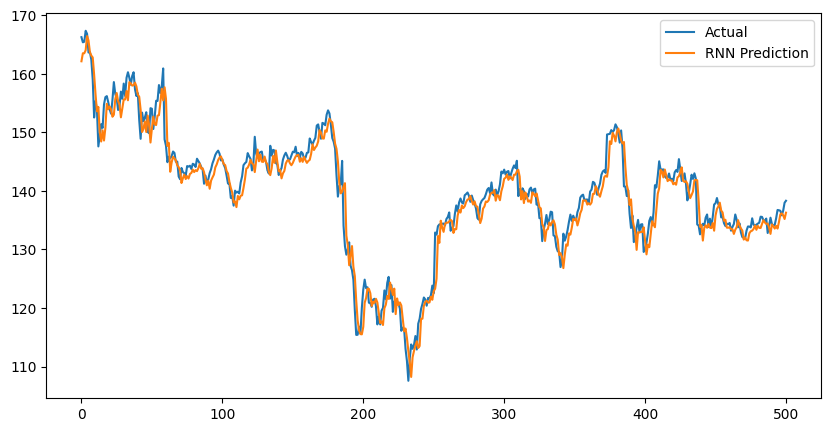

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label="Actual")
plt.plot(rnn_pred, label="RNN Prediction")
plt.legend()
plt.show()


#Task 4: Building a 1D Convolutional Model

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten


#4.1
• Build a 1D CNN model with:

– A Conv1D layer with 5 filters (size 5) and ReLU activation.

– A MaxPooling1D layer (pool size 5).

– A Flatten layer and a Dense output layer.

In [ ]:
cnn_model = Sequential([
    Conv1D(filters=5, kernel_size=5, activation='relu', input_shape=(lookback,1)),
    MaxPooling1D(pool_size=5),
    Flatten(),
    Dense(1)
])

cnn_model.compile(loss='mse', optimizer='adam')
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 5)           │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36 (144.00 B)

 Trainable params: 36 (144.00 B)

 Non-trainable params: 0 (0.00 B)

#4.2
• Train the model and evaluate its performance.

In [ ]:
cnn_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

cnn_pred = cnn_model.predict(X_test)
cnn_pred = scaler.inverse_transform(cnn_pred)

rmse_cnn = sqrt(mean_squared_error(y_test_inv, cnn_pred))
print("CNN RMSE:", rmse_cnn)


Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4550
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2293
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1552
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1027
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0756
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0596
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0542
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0493
Epoch 9/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0457
Epoch 10/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0467
Epoch 11/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0454
Epoch 12/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0477
Epoch 13/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0465
Epoch 14/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0469
Epoch 15/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

#4.3
• Compare results with the plain RNN model.

In [ ]:
cnn_predictions = cnn_model.predict(X_test)

cnn_predictions = scaler.inverse_transform(cnn_predictions)
y_test_actual = scaler.inverse_transform(y_test)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
rmse_cnn = sqrt(mean_squared_error(y_test_actual, cnn_predictions))
print("CNN RMSE:", rmse_cnn)


CNN RMSE: 30.047420109460223


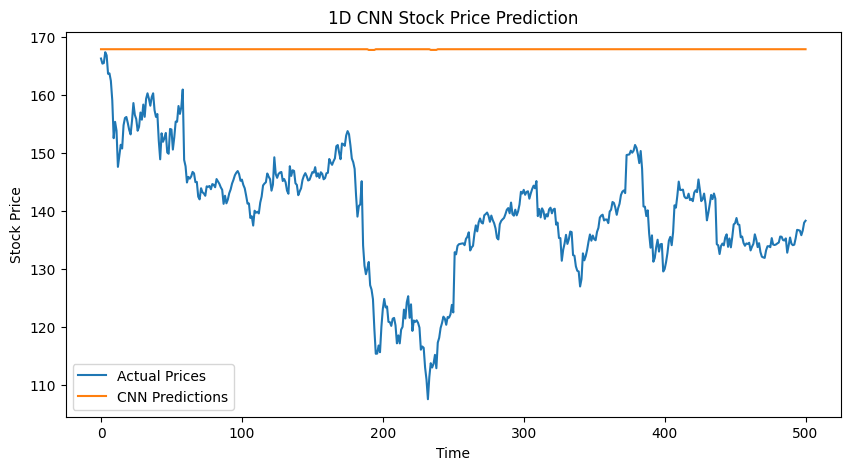

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual Prices')
plt.plot(cnn_predictions, label='CNN Predictions')
plt.title("1D CNN Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


#Task 5: Building a Hybrid (1D CNN + RNN) Model
• Combine 1D convolutions and RNNs in a single model:

– Start with a Conv1D layer (5 filters, size 3).

– Add a SimpleRNN layer with 32 neurons.

– End with a Dense output layer.

In [ ]:
hybrid_model = Sequential([
    Conv1D(filters=5, kernel_size=3, activation='relu', input_shape=(lookback,1)),
    SimpleRNN(32),
    Dense(1)
])

hybrid_model.compile(loss='mse', optimizer='adam')
hybrid_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 8, 5)           │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,269 (4.96 KB)

 Trainable params: 1,269 (4.96 KB)

 Non-trainable params: 0 (0.00 B)

#5.2
• Train and evaluate the hybrid model.

In [ ]:
hybrid_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

hybrid_pred = hybrid_model.predict(X_test)
hybrid_pred = scaler.inverse_transform(hybrid_pred)

rmse_hybrid = sqrt(mean_squared_error(y_test_inv, hybrid_pred))
print("Hybrid RMSE:", rmse_hybrid)


Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0727
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0016
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0014
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.9555e-04
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.2295e-04
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4303e-04
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7005e-04
Epoch 9/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.9985e-04
Epoch 10/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6.1859e-04
Epoch 11/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.9343e-04
Epoch 12/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2548e-04
Epoch 13/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.1698e-04
Epoch 14/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018
Epoch 15/20
126/1


#5.3
• Compare performance with previous models.

In [ ]:
hybrid_predictions = hybrid_model.predict(X_test)

hybrid_predictions = scaler.inverse_transform(hybrid_predictions)
y_test_actual = scaler.inverse_transform(y_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [ ]:
rmse_hybrid = sqrt(mean_squared_error(y_test_actual, hybrid_predictions))
print("Hybrid Model RMSE:", rmse_hybrid)


Hybrid Model RMSE: 2.2867088953859214


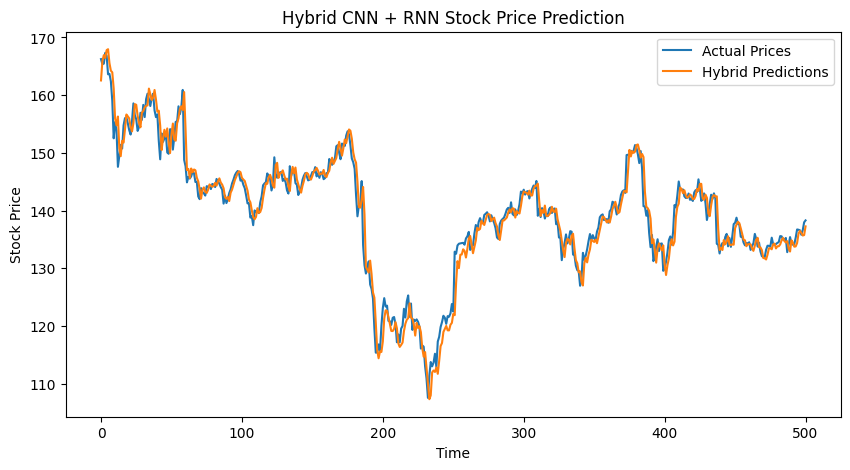

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual Prices')
plt.plot(hybrid_predictions, label='Hybrid Predictions')
plt.title("Hybrid CNN + RNN Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


#Task 6: Activity – Predicting IBM Stock Prices

#6.1
• Load and visualize IBM stock price data.


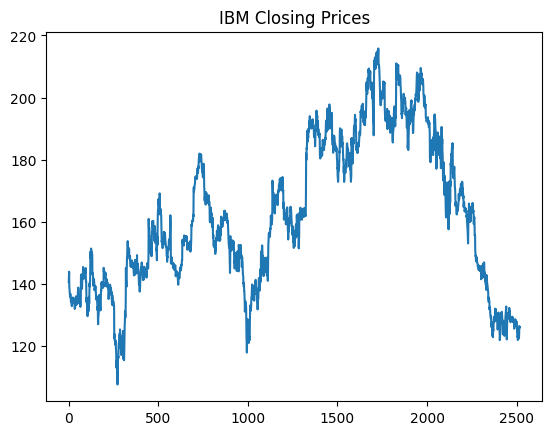

In [ ]:
ibm = pd.read_csv("/content/drive/MyDrive/IBM.csv")
plt.plot(ibm['Close'])
plt.title("IBM Closing Prices")
plt.show()


#6.2
• Split data into train/test sets (75%/25%).


In [ ]:
close_ibm = ibm['Close'].values.reshape(-1,1)

scaler_ibm = MinMaxScaler()
scaled_ibm = scaler_ibm.fit_transform(close_ibm)

lookback = 15
X_ibm, y_ibm = create_sequences(scaled_ibm, lookback)

split = int(0.75 * len(X_ibm))
X_train, X_test = X_ibm[:split], X_ibm[split:]
y_train, y_test = y_ibm[:split], y_ibm[split:]


#6.3
• Scale the data using MinMaxScaler.



In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices)


#6.4
• Create lookback sequences (lookback = 15).

In [ ]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)


#6.5
• Build a hybrid model with dropout for regularization.


In [ ]:
from tensorflow.keras.layers import Conv1D, SimpleRNN, Dense, Dropout

In [ ]:
model = Sequential()
model.add(Conv1D(filters=5,
                 kernel_size=3,
                 activation='relu',
                 input_shape=(lookback, 1)))
model.add(SimpleRNN(32))
model.add(Dropout(0.2))
model.add(Dense(1))

In [ ]:
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 13, 5)          │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,269 (4.96 KB)

 Trainable params: 1,269 (4.96 KB)

 Non-trainable params: 0 (0.00 B)

#6.6
• Train the model and evaluate using RMSE.


In [ ]:
model.fit(X_train,
          y_train,
          epochs=20,
          batch_size=16,
          verbose=1)


Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1565
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0112
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0078
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0062
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0062
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0051
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0044
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0039
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0034
Epoch 12/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0037
Epoch 13/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0028
Epoch 14/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0029
Epoch 15/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - lo

In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
rmse = sqrt(mean_squared_error(y_test_actual, predictions))
print("IBM Stock Prediction RMSE:", rmse)


IBM Stock Prediction RMSE: 3.038177804229306


#6.7
• Plot predictions vs. actual values (full and zoomed-in views).

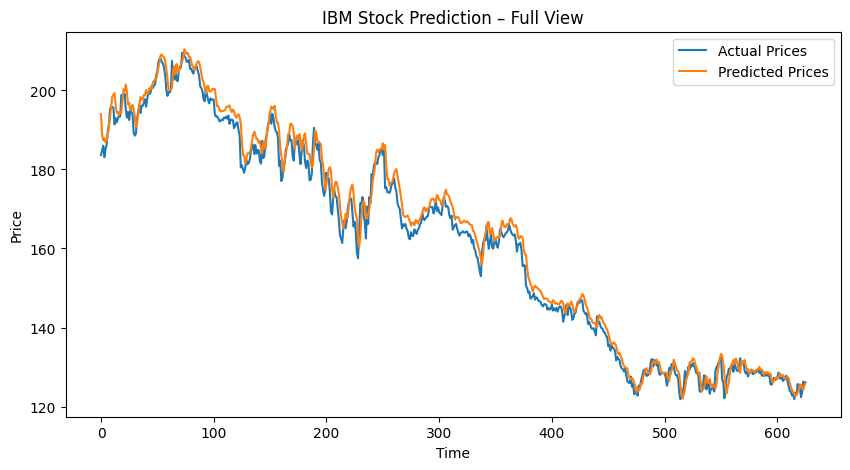

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Prices")
plt.plot(predictions, label="Predicted Prices")
plt.title("IBM Stock Prediction – Full View")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


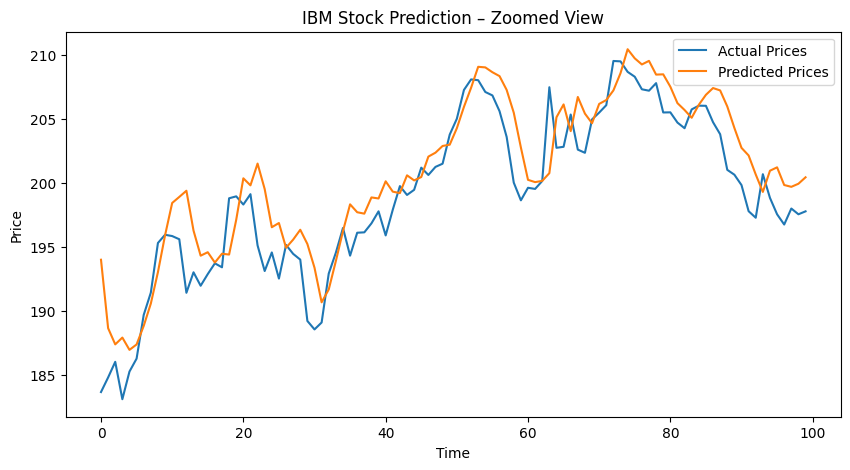

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], label="Actual Prices")
plt.plot(predictions[:100], label="Predicted Prices")
plt.title("IBM Stock Prediction – Zoomed View")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()
